# Báo cáo giữa kì Project
**Lớp:** TTNT166157  
**Nhóm:** 10  
**Giảng viên:** Đỗ Tiến Dũng

# 1. Thông tin chung

### Thành viên
- Đinh Ngọc Khánh 20235752
- Nguyễn Hải Dương 20235692
- Nguyễn Quang Thiện 20235838
- Lương Văn Hưng 20235740

### Lịch thực hiện
- W26: Đăng ký nhóm
- W28: Chốt danh sách nhóm project 
- W29: Chốt tên project
- W35: Báo cáo giữa kì, tiến độ project (9/5)
- W40: Báo cáo cuối kì project (13/6)

# 2.Tiến độ giữa kì

## Bài toán
                      
                       🤖 **:CleanerBot:** 🤖                           

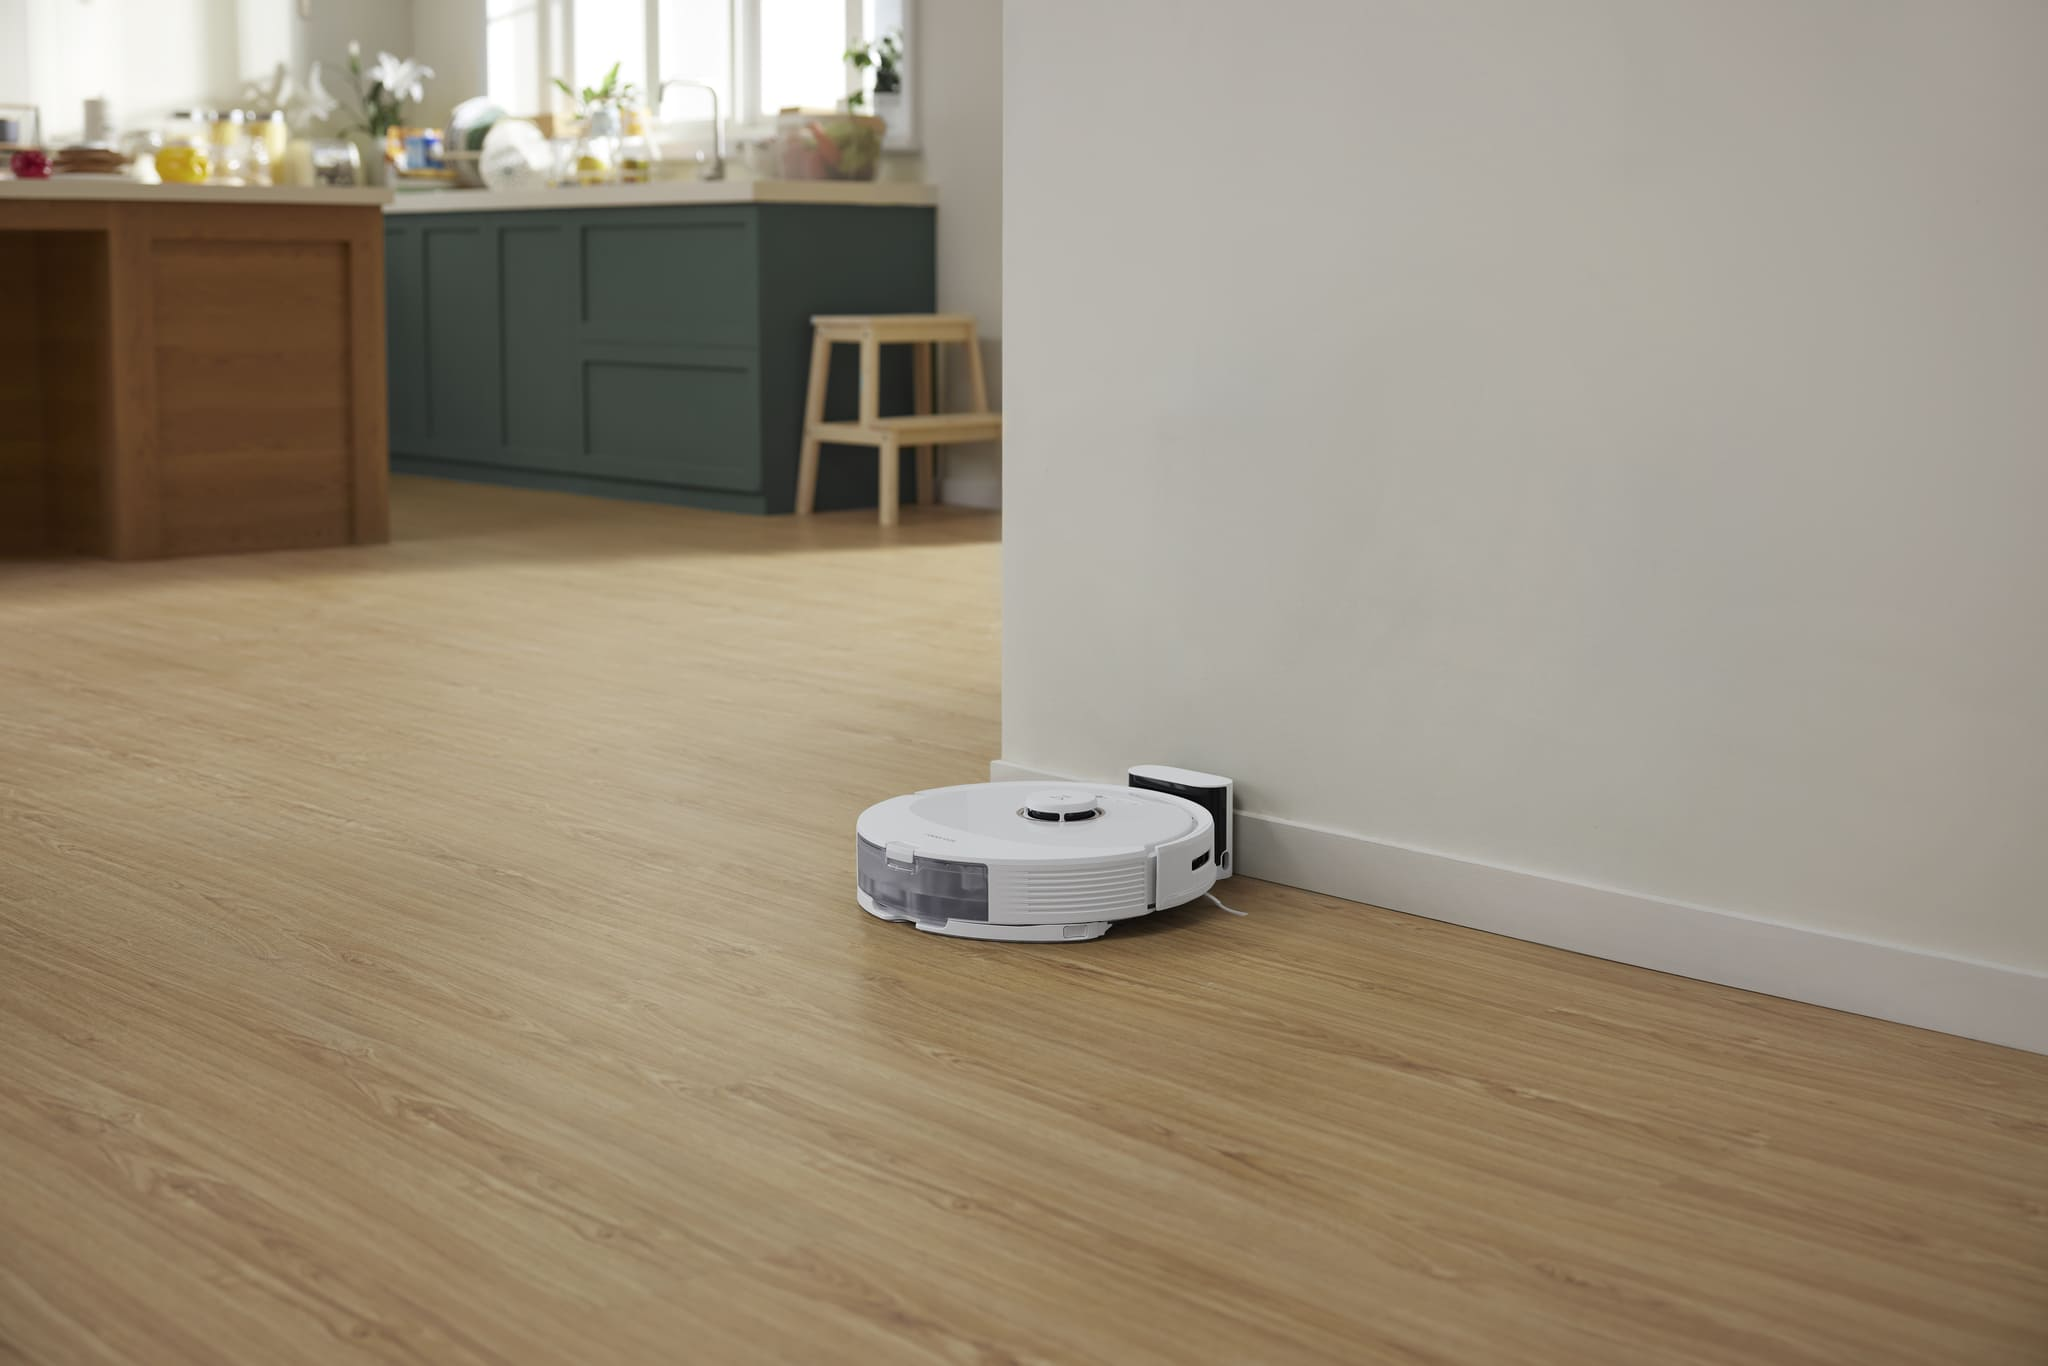

*Trong sản phẩm này Robot sẽ **tự động** tìm rác bằng các thuật toán được cài đặt sẵn với môi trường là một mê cung được khởi tạo gồm có chướng ngại vật , trạm sạc và thùng rác.*

## Phân tích bài toán

### 1. Tác tử
- Performance (Tiêu chí) : Số lượng rác dọn được , chi phí di chuyển thấp nhất, số lần va chạm vật cản
- Evironment : có thể trên sàn nhà , rác , chướng ngại vật cố định và trạm sạc
- Actuators (Bộ phận hành động) : Bánh xe ( tiến , lùi , rẽ sang trái/ phải ) , bộ phận hút rác
- Sensors ( Cảm biến) : camera , Bộ đo năng lượng pin , có thể thêm quét laser

### 2. Môi trường
- Quan sát được 1 phần : chỉ nhìn được qua camera hoặc trong tầm cảm biến , ko biết rác nơi khác
- Ngẫu nhiên : Rác hồi chiêu và có thể có thêm vật cản di chuyển
- Động : Môi trường luôn có thể thay đổi khi robot di chuyển 
- Liên tiếp : Hành động đi hút rác có thể ảnh hưởng đến khả năng hết pin trong tương lai
- Tác tử đơn

### 3. Kiểu tác tử
- Tác tử dựa trên lợi ích : tối ưu tài nguyên pin 
- Tác tử phản xạ dựa trên mô hình  

## Phân công
- Đinh Ngọc Khánh: Thiết kế cấu trúc file, thiết kế UI/UX, cài đặt thuật toán A* cho robot
- Nguyễn Hải Dương: Chuẩn bị tài liệu, cài đặt thuật toán BFS cho robot
- Nguyễn Quang Thiện: Làm báo cáo, cài đặt thuật toán IDS cho robot
- Lương Văn Hưng : Tạo bảng so sánh, cài đặt thuật toán IDA* cho robot

## Chương trình

### Models

File models.js định nghĩa cấu trúc dữ liệu cho Robot và Môi trường, thiết lập nền tảng để quản lý trạng thái tác tử và các thành phần vật lý trong không gian mô phỏng. Đây là cơ sở dữ liệu giúp robot nhận biết năng lượng, sức chứa và vị trí vật cản để ra quyết định hành động.

In [ ]:
// 1. Định nghĩa các hành động có thể thực hiện của Robot
export const ACTIONS = Object.freeze({
  UP: "up", DOWN: "down", LEFT: "left", RIGHT: "right", // Hành động theo phương hướng
  CHARGE: "charge",       // Hành động sạc
  SUCK_TRASH: "suck_trash", // Hành động hút rác
  LET_TRASH_OUT: "let_trash_out", // Hành động đổ rác
  STAY: "stay"
});

// 2. Lớp Robot: Đại diện cho tác tử với các cảm biến nội tại
export class Robot {
  constructor({ battery = 100, capacity = 0, maxCapacity = 5, x = 0, y = 0 } = {}) {
    this.battery = battery;         // Trạng thái pin (Sensor: Bộ đo năng lượng)
    this.capacity = capacity;       // Lượng rác hiện tại trong bồn chứa
    this.maxCapacity = maxCapacity; // Sức chứa tối đa (Giới hạn tài nguyên)
    this.x = x;                     // Tọa độ X hiện tại
    this.y = y;                     // Tọa độ Y hiện tại
  }
}

// 3. Lớp CleanerMap: Đại diện cho môi trường (Environment)
export class CleanerMap {
  constructor({
    grid_size_x = 8, grid_size_y = 8,
    trashPositions = [],       // Vị trí rác (Mục tiêu cần dọn)
    obstaclePositions = [],    // Vị trí vật cản (Ràng buộc môi trường)
    chargingStation = { x: 0, y: 0 }, // Vị trí trạm sạc
    trashCan = { x: 7, y: 7 },       // Vị trí thùng rác tổng
    done = false               // Trạng thái hoàn thành bài toán
  } = {}) {
    this.grid_size_x = grid_size_x;
    this.grid_size_y = grid_size_y;
    this.trashPositions = trashPositions;
    this.obstaclePositions = obstaclePositions;
    this.chargingStation = chargingStation;
    this.trashCan = trashCan;
    this.done = done;
  }
}

// 4. Lớp SimulationState: Tổng hợp toàn bộ trạng thái hệ thống tại một thời điểm
export class SimulationState {
  constructor({ robot, map, config = {}, steps = 0, latestAction = null }) {
    this.robot = robot;      // Đối tượng Robot
    this.map = map;          // Đối tượng Bản đồ
    this.steps = steps;      // Tổng số bước di chuyển (Cost)
    this.latestAction = latestAction; // Hành động vừa thực hiện
  }
}

### DFS

In [ ]:
// 1. Tìm mục tiêu rác gần nhất và đảm bảo đủ pin để quay về an toàn
findNearestSafeTrashTarget(state) {
  const stack = [{ position: state.robot, path: [state.robot] }]; // Sử dụng ngăn xếp
  const visited = new Set([this.positionKey(state.robot)]);

  while (stack.length > 0) {
    const node = stack.pop(); // Lấy phần tử cuối cùng để đi sâu nhất
    const current = node.position;

    // Goal Test: Là rác VÀ đủ pin để hoàn thành chu trình (hút rác -> sạc pin)
    if (this.isTrashPosition(state, current) && this.hasEnoughBatteryForTarget(state, current)) {
      return { target: current, route: node.path };
    }

    // Mở rộng các trạng thái lân cận
    for (const neighbor of [...this.getMoveCandidates(current)].reverse()) {
      const key = this.positionKey(neighbor.position);
      if (!visited.has(key) && this.canMoveTo(state, neighbor.position)) {
        visited.add(key);
        stack.push({ position: neighbor.position, path: [...node.path, neighbor.position] });
      }
    }
  }
  return null;
}

// 2. Tìm đường đi đến một vị trí chỉ định
findPath(state, start, goal) {
  const stack = [{ position: start, path: [start] }];
  const visited = new Set([this.positionKey(start)]);

  while (stack.length > 0) {
    const node = stack.pop();
    if (samePosition(node.position, goal)) return node.path; // Đạt trạng thái đích

    for (const neighbor of [...this.getMoveCandidates(node.position)].reverse()) {
      const key = this.positionKey(neighbor.position);
      if (!visited.has(key) && this.canMoveTo(state, neighbor.position)) {
        visited.add(key);
        stack.push({ position: neighbor.position, path: [...node.path, neighbor.position] });
      }
    }
  }
  return null;
}

### BFS

In [ ]:
// 1. Quyết định hành động tiếp theo dựa trên trạng thái robot
computeNextAction(state) {
  const { robot, map } = state;

  // Logic ưu tiên: Đổ rác -> Sạc pin -> Hút rác -> Tìm mục tiêu mới
  if (this.isAtTrashCan(state) && this.shouldEmptyTrash(state)) return ACTIONS.LET_TRASH_OUT;
  if (this.isAtChargingStation(state) && this.shouldCharge(state)) return ACTIONS.CHARGE;
  if (this.hasTrashAtRobot(state) && robot.capacity < robot.maxCapacity) return ACTIONS.SUCK_TRASH;

  let target = this.chooseWorkTarget(state); // Chọn mục tiêu ưu tiên nhất
  let route = this.getRouteToTarget(state, target); // Tìm đường bằng BFS
  
  return this.getActionForRouteStep(route[0], route[1]); // Trả về hướng di chuyển
}

// 2. Tìm đường đi ngắn nhất bằng hàng đợi (Queue)
findPath(state, start, goal) {
  const queue = [{ position: start, path: [start] }];
  const visited = new Set([this.positionKey(start)]);

  while (queue.length > 0) {
    const node = queue.shift(); // FIFO: Duyệt các nút gần trước
    if (samePosition(node.position, goal)) return node.path;

    for (const neighbor of this.getMoveCandidates(node.position)) {
      const key = this.positionKey(neighbor.position);
      if (!visited.has(key) && this.canMoveTo(state, neighbor.position)) {
        visited.add(key);
        queue.push({ 
          position: neighbor.position, 
          path: [...node.path, neighbor.position] 
        });
      }
    }
  }
  return null;
}

// 3. Logic kiểm tra an toàn năng lượng
hasEnoughBatteryForTarget(state, target) {
  const requiredBattery = this.getRequiredBatteryForTarget(state, target);
  return state.robot.battery >= requiredBattery; // Đảm bảo đủ pin đi và về trạm sạc
}

### IDS

In [ ]:
// 1. Tìm mục tiêu rác an toàn bằng cách tăng dần giới hạn độ sâu
findNearestSafeTrashTarget(state) {
  const maxDepth = state.map.grid_size_x * state.map.grid_size_y;

  for (let limit = 0; limit <= maxDepth; limit++) {
    // Thực hiện DFS giới hạn ở độ sâu 'limit'
    const result = this.depthLimitedTargetSearch(state, state.robot, limit);
    if (result) return result; 
  }
  return null;
}

// 2. Tìm đường đi ngắn nhất đến vị trí chỉ định bằng chiến lược IDS
findPath(state, start, goal) {
  const maxDepth = state.map.grid_size_x * state.map.grid_size_y;

  for (let limit = 0; limit <= maxDepth; limit++) {
    const path = [{ x: start.x, y: start.y }];
    const visited = new Set([this.positionKey(start)]);

    const result = this.depthLimitedTraverse(state, path, visited, limit, (currentPath) => {
      const current = currentPath[currentPath.length - 1];
      return samePosition(current, goal) ? currentPath : null;
    });

    if (result) return result;
  }
  return null;
}

// 3. Hàm cốt lõi: Duyệt giới hạn độ sâu và quay lui (Backtracking)
depthLimitedTraverse(state, path, pathSet, remainingDepth, onFound) {
  const current = path[path.length - 1];
  
  // Kiểm tra điều kiện dừng tại nút hiện tại
  const found = onFound(path);
  if (found) return found;
  if (remainingDepth === 0) return null; // Hết giới hạn độ sâu

  // Duyệt các nhánh con (Move Candidates)
  for (const neighbor of [...this.getMoveCandidates(current)].reverse()) {
    const key = this.positionKey(neighbor.position);
    
    if (!pathSet.has(key) && this.canMoveTo(state, neighbor.position)) {
      path.push(neighbor.position);
      pathSet.add(key);

      const result = this.depthLimitedTraverse(state, path, pathSet, remainingDepth - 1, onFound);
      if (result) return result;

      path.pop(); // QUAY LUI: Giải phóng bộ nhớ sau khi duyệt hết nhánh
      pathSet.delete(key);
    }
  }
  return null;
}

### GREEDY

In [ ]:
// 1. Máy trạng thái quyết định hành động tức thời
computeNextAction(state) {
  const { robot, map } = state;

  // Kiểm tra các hành động tại chỗ ưu tiên: Đổ rác -> Sạc pin -> Hút rác
  if (this.isAtTrashCan(state) && robot.capacity > 0) return ACTIONS.LET_TRASH_OUT;
  if (this.isAtChargingStation(state) && this.shouldCharge(state)) return ACTIONS.CHARGE;
  if (this.hasTrashAtRobot(state) && robot.capacity < robot.maxCapacity) return ACTIONS.SUCK_TRASH;

  // Xác định mục tiêu công việc tiếp theo
  let target = this.chooseWorkTarget(state);

  // Nếu mục tiêu quá xa so với lượng pin hiện tại -> Chuyển hướng sang trạm sạc
  if (target && !this.hasEnoughBatteryForTarget(state, target)) {
    target = map.chargingStation;
  }

  if (!target) return this.getChargingAction(state); // Cố gắng quay về trạm sạc

  // Thực hiện di chuyển tham lam về phía mục tiêu đã chọn
  return this.chooseMoveTowardTarget(state, target);
}

// 2. Chiến lược di chuyển: Luôn chọn hướng làm giảm khoảng cách Manhattan nhanh nhất
chooseMoveTowardTarget(state, target) {
  const candidates = this.getMoveCandidates(state.robot);

  // Sắp xếp các hướng di chuyển theo mức độ ưu tiên: hướng nào gần đích nhất đứng trước
  candidates.sort((a, b) => 
    this.manhattanDistance(a.position, target) - this.manhattanDistance(b.position, target)
  );

  // Chọn hành động hợp lệ đầu tiên (không va vào vật cản)
  const bestMove = candidates.find(c => this.canMoveTo(state, c.position));
  return bestMove ? bestMove.action : ACTIONS.STAY;
}

// 3. Tính toán chi phí năng lượng dựa trên khoảng cách hình học
getRequiredBatteryForTarget(state, fromPosition, target) {
  const batteryLoss = this.getBatteryLoss(state);
  
  // Chi phí di chuyển trực tiếp dựa trên khoảng cách Manhattan
  let requiredBattery = this.manhattanDistance(fromPosition, target) * batteryLoss;

  // Cộng thêm chi phí dự phòng để quay về trạm sạc an toàn sau khi tới mục tiêu
  if (!samePosition(target, state.map.chargingStation)) {
    requiredBattery += this.manhattanDistance(target, state.map.chargingStation) * batteryLoss;
  }
  
  return requiredBattery;
}

### A*

In [ ]:
// 1. Tìm mục tiêu rác tối ưu nhất dựa trên khoảng cách và năng lượng
findNearestSafeTrashTarget(state) {
  // Sắp xếp danh sách rác theo khoảng cách Manhattan để ưu tiên xử lý
  const sortedTrash = [...state.map.trashPositions].sort((a, b) => 
    this.manhattanDistance(state.robot, a) - this.manhattanDistance(state.robot, b)
  );

  for (const trash of sortedTrash) {
    const route = this.findPath(state, state.robot, trash); // Tìm đường bằng A*
    
    // Kiểm tra: Phải có đường đi VÀ đủ pin để hoàn thành nhiệm vụ an toàn
    if (route && this.hasEnoughBatteryForTarget(state, trash)) {
      return { target: trash, route: route };
    }
  }
  return null;
}

// 2. Logic cốt lõi A*: Duyệt các nút dựa trên điểm số fScore
runAStar(state, start, goal) {
  const openSet = [{ position: start, g: 0 }]; // Tập các nút chờ duyệt
  const gScore = new Map([[this.positionKey(start), 0]]); // Chi phí thực từ điểm xuất phát
  const fScore = new Map([[this.positionKey(start), this.manhattanDistance(start, goal)]]);

  while (openSet.length > 0) {
    // Chọn nút có f(n) thấp nhất trong tập chờ (Priority Queue logic)
    const currentIndex = this.findLowestScoreIndex(openSet, goal, gScore, fScore);
    const current = openSet.splice(currentIndex, 1)[0].position;

    if (samePosition(current, goal)) return this.reconstructPath(); // Tìm thấy đường đi

    for (const neighbor of this.getMoveCandidates(current)) {
      if (!this.canMoveTo(state, neighbor.position)) continue;

      const tentativeG = gScore.get(this.positionKey(current)) + 1; // g(n) mới

      // Nếu tìm thấy một đường đi tới nút lân cận tốt hơn đường cũ
      if (tentativeG < (gScore.get(this.positionKey(neighbor.position)) ?? Infinity)) {
        gScore.set(this.positionKey(neighbor.position), tentativeG);
        // f(n) = g(n) + h(n)
        fScore.set(this.positionKey(neighbor.position), tentativeG + this.manhattanDistance(neighbor.position, goal));
        
        openSet.push({ position: neighbor.position, g: tentativeG });
      }
    }
  }
  return null;
}

// 3. Hàm Heuristic (Khoảng cách Manhattan)
manhattanDistance(a, b) {
  return Math.abs(a.x - b.x) + Math.abs(a.y - b.y);
}

### IDA*

In [ ]:
// 1. Tìm mục tiêu rác an toàn bằng cách sử dụng lộ trình tối ưu từ IDA*
findNearestSafeTrashTarget(state) {
  const sortedTrash = [...state.map.trashPositions].sort((a, b) => 
    this.manhattanDistance(state.robot, a) - this.manhattanDistance(state.robot, b)
  );

  for (const trash of sortedTrash) {
    const route = this.findPath(state, state.robot, trash); // Gọi IDA* thông qua findPath
    
    // Kiểm tra an toàn: Có đường đi và đủ pin để thực hiện nhiệm vụ
    if (route && this.hasEnoughBatteryForTarget(state, trash)) {
      return { target: trash, route: route };
    }
  }
  return null;
}

// 2. Logic điều khiển lặp ngưỡng (Iterative Bound)
runIDAStar(state, start, goal) {
  let bound = this.manhattanDistance(start, goal); // Ngưỡng f(n) khởi đầu là h(start)
  
  while (bound <= (state.map.grid_size_x * state.map.grid_size_y)) {
    // Thực hiện tìm kiếm giới hạn bởi chi phí ước lượng (DLS-like)
    const result = this.depthLimitedSearch(state, goal, [start], new Set(), 0, bound);

    if (result === SEARCH_FOUND) return path; // Tìm thấy lộ trình tối ưu
    if (!Number.isFinite(result)) return null; 
    
    bound = result; // Cập nhật bound mới là giá trị f(n) nhỏ nhất vượt ngưỡng cũ
  }
}

// 3. Tìm kiếm giới hạn độ sâu dựa trên hàm đánh giá (F-limit Search)
depthLimitedSearch(state, goal, path, pathSet, costSoFar, bound) {
  const current = path[path.length - 1];
  const estimate = costSoFar + this.manhattanDistance(current, goal); // f(n) = g(n) + h(n)

  // CẮT TỈA (Pruning): Nếu chi phí ước lượng vượt quá ngưỡng hiện tại
  if (estimate > bound) return estimate;
  if (samePosition(current, goal)) return SEARCH_FOUND;

  let nextBound = Infinity;
  // Sắp xếp các hướng đi tiềm năng để tăng tốc độ tìm kiếm
  const neighbors = this.getSortedMoveCandidates(current, goal);

  for (const neighbor of neighbors) {
    if (!this.canMoveTo(state, neighbor.position) || pathSet.has(key(neighbor))) continue;

    path.push(neighbor.position);
    pathSet.add(key(neighbor));
    
    const result = this.depthLimitedSearch(state, goal, path, pathSet, costSoFar + 1, bound);
    if (result === SEARCH_FOUND) return SEARCH_FOUND;
    
    if (result < nextBound) nextBound = result; // Lưu lại giá trị f(n) nhỏ nhất để làm bound tiếp theo
    
    path.pop(); // Quay lui (Backtracking) để tiết kiệm bộ nhớ O(d)
    pathSet.delete(key(neighbor));
  }
  return nextBound;
}

## Vấn đề gặp phải

* **Chưa áp dụng đầy đủ các thuật toán nâng cao trong chương trình học:** Hiện tại, nhóm mới chỉ tập trung vào các thuật toán tìm kiếm mù (BFS, DFS, IDS) và tìm kiếm có thông tin (A*, IDA*)
* **Chưa tối ưu hoàn toàn thuật toán A_star và IDA_star:** Hàm đánh giá Heuristic (khoảng cách Manhattan) hiện tại hoạt động tốt trên map nhỏ, nhưng với map kích thước lớn và nhiều vật cản phức tạp, chi phí tính toán đường đi vẫn còn cao.
* **Thiếu hụt hệ thống minh họa tiến trình thuật toán:** Trong bản demo giữa kỳ, hệ thống chưa hiển thị rõ ràng cách robot "tư duy". Người xem mới chỉ thấy kết quả cuối cùng là đường đi mà chưa quan sát được quá trình thuật toán duyệt nút, tính toán.